In [1]:
import gc
import os
import time
import numpy as np
import pandas as pd
import psutil
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import mlflow
import pynvml
import json


/home/yedhu/workspace/venvs/quantization-venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
_proc = psutil.Process(os.getpid())

In [3]:
DATASET = "SHAREGPT" # TOY , SHAREGPT
LOAD_CACHE = True
SAMPLE_SIZE = 128
EXPECTED_LEN = "DYNAMIC" # STATIC / DYNAMIC

In [4]:
MODEL_FP16 = "meta-llama/Llama-3.2-3B-Instruct"
MODEL_AWQ  = "./models/llama-3.2-3b-instruct-awq-custom"
MODEL_GPTQ = "./models/llama-3.2-3b-instruct-gptq-custom"

# Dataset

## Toy Dataset

In [5]:
# 1. Define the dataset
PROMPTS = [
    ("simple_qa_1",   "What is the capital of Japan?", 32),
    ("simple_qa_2",   "Who wrote the play 'Hamlet'?", 32),
    ("reasoning_1",   "If a train travels 60 km in 45 minutes, what is its average speed in km/h? Explain.", 128),
    ("reasoning_2",   "A bat and a ball cost $1.10 together. The bat costs $1.00 more than the ball. How much is the ball? Reason step by step.", 128),
    ("coding_1",      "Write a Python function that returns the n-th Fibonacci number using memoization.", 200),
    ("coding_2",      "Write a SQL query to find the second highest salary from an Employees table.", 128),
    ("summarization", "Summarize the following in one sentence: Quantization reduces the numerical precision of model weights and activations, lowering memory and bandwidth needs while usually keeping accuracy close to the full-precision baseline.", 64),
    ("long_context",  "Here are five facts: (1) The sky is blue. (2) Water boils at 100C at sea level. (3) Paris is in France. (4) Honey does not spoil. (5) Spiders have eight legs. Which fact is about cooking, and which is about geography?", 96),
    ("math_1",        "Compute 17 * 23 and show the multiplication steps.", 96),
    ("math_2",        "What is the derivative of f(x) = 3x^2 + 2x - 5 with respect to x?", 64),
]



In [6]:
if DATASET == "TOY":
    toy_dataset = pd.DataFrame(PROMPTS, columns=["name", "prompt", "expected_len"])

## Static Benchmark Dataset - ShareGPT

In [7]:
from datasets import load_dataset


def load_sharegpt_benchmark_data(target_sample_size: int = 64) -> pd.DataFrame:
    """
    Loads real-world conversational prompts from ShareGPT for throughput benchmarking.
    Enforces that the final dataset size is a perfect multiple of 8.
    """
    # Force the sample size to be a multiple of 8 (which is also a multiple of 4)
    valid_sample_size = (target_sample_size // 8) * 8
    if valid_sample_size < 8:
        valid_sample_size = 8 # Ensure at least one valid batch
        
    print(f"Requested {target_sample_size} prompts. Rounding to {valid_sample_size} to perfectly fit BATCH_SIZE=8.")

    # Load the standard Vicuna ShareGPT dataset directly from Hugging Face
    # We use streaming=True so we don't have to download the entire massive dataset
    dataset = load_dataset("anon8231489123/ShareGPT_Vicuna_unfiltered", 
        data_files="ShareGPT_V3_unfiltered_cleaned_split.json",
        split="train", 
        streaming=True)
    
    # # Extract the very first row from the stream
    # first_row = next(iter(dataset))

    # # Print it beautifully with indentation
    # print("\n--- FIRST DATASET ROW ---")
    # print(json.dumps(first_row, indent=2))
    
    # input()

    prompts_data = []
    
    for row in dataset:
        conversations = row.get("conversations", [])
        if not conversations:
            continue
        try:
            # Extract the very first human prompt from the conversation thread
            # first_turn = conversations[0]
            first_turn = json.loads(conversations[0])
            if first_turn.get("from") == "human" and first_turn.get("value"):
                prompt_text = first_turn["value"]
                
                # To test pure system throughput without the "Padding Tax", 
                # performance benchmarks often lock the expected generation length 
                # to a static number (e.g., 256 tokens) for every prompt.
                expected_len = 256 
                
                prompts_data.append({
                    "name": f"sharegpt_{row.get('id', len(prompts_data))}", 
                    "prompt": prompt_text, 
                    "expected_len": expected_len
                })
        except json.JSONDecodeError:
            continue
            
        # Stop streaming once we hit our mathematically perfect batch size
        if len(prompts_data) >= valid_sample_size:
            break
            
    return pd.DataFrame(prompts_data)



In [8]:
# ==========================================
# Initialize DataFrame for the benchmark loop
# ==========================================
# Choose approppriate sample size for testing

if DATASET == 'SHAREGPT' and EXPECTED_LEN == 'STATIC' and LOAD_CACHE != True:

    static_shareGPT_dataset = load_sharegpt_benchmark_data(target_sample_size=SAMPLE_SIZE)

    # static_shareGPT_dataset.to_csv(f"datasets/shareGPT_custom/static_shareGPT_dataset_{sample_size}.csv",header=True)

    file_path = f"datasets/shareGPT_custom/static_shareGPT_dataset_{SAMPLE_SIZE}.jsonl"
    static_shareGPT_dataset.to_json(file_path, orient="records", lines=True, force_ascii=False)


In [9]:
if DATASET == 'SHAREGPT' and EXPECTED_LEN == 'STATIC' and LOAD_CACHE:

    file_path = f"datasets/shareGPT_custom/static_shareGPT_dataset_{SAMPLE_SIZE}.jsonl"
    static_shareGPT_dataset = pd.read_json(file_path, orient="records", lines=True)
    # Optional: Sort by expected_len to eliminate padding tax if you decide 
    # to use dynamic expected lengths instead of the static 256 above.
    dataset = static_shareGPT_dataset.sort_values(by="expected_len").reset_index(drop=True)

## Dynamic Benchmark Dataset - ShareGPT

In [10]:
from datasets import load_dataset


def load_dynamic_sharegpt_data(tokenizer, target_sample_size: int = 64) -> pd.DataFrame:
    """
    Loads real-world prompts from ShareGPT and dynamically calculates 
    expected_len based on the actual assistant response token count.
    """
    # Enforce perfect batch-size division
    valid_sample_size = (target_sample_size // 8) * 8
    if valid_sample_size < 8:
        valid_sample_size = 8
        
    print(f"Loading {valid_sample_size} prompts with dynamic response lengths...")

    # Stream the dataset from Hugging Face
    dataset = load_dataset("anon8231489123/ShareGPT_Vicuna_unfiltered", 
        data_files="ShareGPT_V3_unfiltered_cleaned_split.json",
        split="train", 
        streaming=True)
    
    prompts_data = []
    
    for row in dataset:
        conversations = row.get("conversations", [])
        # We need at least 2 turns: index 0 (human prompt) and index 1 (model response)
        if len(conversations) >= 2:
            try:
            
                # user_turn = conversations[0]
                # assistant_turn = conversations[1]
                user_turn = json.loads(conversations[0])
                assistant_turn = json.loads(conversations[1])
                
                # Verify the structure is Human -> GPT
                if (user_turn.get("from") == "human" and user_turn.get("value") and 
                    assistant_turn.get("from") == "gpt" and assistant_turn.get("value")):
                    
                    prompt_text = user_turn["value"]
                    assistant_text = assistant_turn["value"]
                    
                    # Dynamically calculate the token count of the actual response
                    # we use add_special_tokens=False to count raw text tokens cleanly
                    response_tokens = tokenizer.encode(assistant_text, add_special_tokens=False)
                    dynamic_len = len(response_tokens)
                    
                    # Skip edge cases (e.g., empty responses or massive outliers that cause OOM)
                    if dynamic_len < 10 or dynamic_len > 1024:
                        continue
                        
                    prompts_data.append({
                        "name": f"sharegpt_{row.get('id', len(prompts_data))}", 
                        "prompt": prompt_text, 
                        "expected_len": dynamic_len
                    })
            except json.JSONDecodeError:
                # Silently drop malformed rows to keep the pipeline moving
                continue
            
        if len(prompts_data) >= valid_sample_size:
            break
            
    return pd.DataFrame(prompts_data)



In [11]:
# ==========================================
# How to call it in your script
# ==========================================
# Pass your active tokenizer instance straight into the function
if DATASET == 'SHAREGPT' and EXPECTED_LEN == 'DYNAMIC' and LOAD_CACHE != True:

    tokenizer = AutoTokenizer.from_pretrained(MODEL_FP16)

    dynamic_shareGPT_dataset = load_dynamic_sharegpt_data(tokenizer=tokenizer, target_sample_size=128)

    file_path = f"datasets/shareGPT_custom/dynamic_shareGPT_dataset_{SAMPLE_SIZE}.jsonl"
    dynamic_shareGPT_dataset.to_json(file_path, orient="records", lines=True, force_ascii=False)



In [12]:
if DATASET == 'SHAREGPT' and EXPECTED_LEN == 'DYNAMIC' and LOAD_CACHE:

    file_path = f"datasets/shareGPT_custom/dynamic_shareGPT_dataset_{SAMPLE_SIZE}.jsonl"

    dynamic_shareGPT_dataset = pd.read_json(file_path, orient="records", lines=True)
    # CRITICAL: Because lengths are highly variable now, sorting is mandatory 
    # to group matching workloads and protect your GPU from the Padding Tax!
    dataset = dynamic_shareGPT_dataset.sort_values(by="expected_len").reset_index(drop=True)

# Metrics

In [13]:
def gpu_allocated_gb(device=DEVICE): return torch.cuda.memory_allocated() / 1024**3 if device == "cuda" else 0.0
def gpu_reserved_gb(device=DEVICE): return torch.cuda.memory_reserved() / 1024**3 if device == "cuda" else 0.0
def gpu_peak_reserved_gb(device=DEVICE): return torch.cuda.max_memory_reserved() / 1024**3 if device == "cuda" else 0.0
def gpu_peak_gb(device=DEVICE): return torch.cuda.max_memory_allocated() / 1024**3 if device == "cuda" else 0.0

def cpu_resident_gb(): return _proc.memory_info().rss / 1024**3
def cpu_virtual_gb(): return _proc.memory_info().vms / 1024**3

## PyNVML

In [14]:
def get_gpu_absolute_memory_usage():
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)  # Assuming single GPU
    mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
    return mem_info.used / 1024**3  # Convert bytes to GB

In [15]:
def get_gpu_blindspot_gb(device_index=0):
    if not torch.cuda.is_available():
        return 0.0
        
    # 1. Query the NVIDIA driver for the absolute total memory used 
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(device_index)
    info = pynvml.nvmlDeviceGetMemoryInfo(handle)
    total_system_used_gb = info.used / (1024**3)
    pynvml.nvmlShutdown()
    
    # 2. Query PyTorch for the total memory it is managing in its caching allocator
    pytorch_reserved_gb = torch.cuda.memory_reserved(device_index) / (1024**3)
    
    # 3. The difference is the untracked overhead
    blindspot_gb = total_system_used_gb - pytorch_reserved_gb
    
    return blindspot_gb

In [16]:
import pynvml
import threading
import time

class AsyncGPUMonitor:
    def __init__(self, device_index=0, poll_interval=0.1):
        self.device_index = device_index
        self.poll_interval = poll_interval
        self.utilization_rates = []
        self.is_running = False
        self.monitor_thread = None
        
        # Initialize NVML and grab the handle for your RTX 5080
        pynvml.nvmlInit()
        self.handle = pynvml.nvmlDeviceGetHandleByIndex(self.device_index)

    def _poll_gpu(self):
        """The background worker that polls compute utilization."""
        while self.is_running:
            # Get the SM compute utilization (returns an integer percentage 0-100)
            utilization = pynvml.nvmlDeviceGetUtilizationRates(self.handle)
            self.utilization_rates.append(utilization.gpu)
            time.sleep(self.poll_interval)

    def __enter__(self):
        """Starts the background thread when entering a 'with' block."""
        self.utilization_rates = []
        self.is_running = True
        self.monitor_thread = threading.Thread(target=self._poll_gpu, daemon=True)
        self.monitor_thread.start()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Stops the thread when exiting the block and calculates metrics."""
        self.is_running = False
        if self.monitor_thread:
            self.monitor_thread.join()
            
    def get_metrics(self):
        """Returns the average and max compute utilization for the captured window."""
        if not self.utilization_rates:
            return 0.0, 0.0
        
        avg_util = float(np.mean(self.utilization_rates))
        max_util = float(np.max(self.utilization_rates))
        return avg_util, max_util

    def cleanup(self):
        """Frees NVML resources when the entire script finishes."""
        pynvml.nvmlShutdown()

## Local Logging

In [17]:
metric_df = pd.DataFrame(
    columns=["LLAMA_3_2_3B_FP16", "LLAMA_3_2_3B_AWQ_CUSTOM","LLAMA_3_2_3B_GPTQ_CUSTOM"],
    index=pd.MultiIndex.from_tuples([], names=["metrics", "stage"])
)

In [18]:
def add_metric(df, metric, stage, model, value):
    # Create row if metric doesn't exist
    key = (metric, stage)
    if key not in df.index:
        df.loc[key, :] = [None] * len(df.columns)

    # Update the appropriate model column
    df.loc[key, model] = value
    return df

## MLFlow Logging

In [19]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Quantization Benchmarking")
print(mlflow.get_tracking_uri())

http://localhost:5000


In [20]:
def mlflow_start_run(name: str):
    if mlflow.active_run():
        mlflow.end_run()
    return mlflow.start_run(run_name=name)

# Utils

In [21]:
def gpu_reset_peak(device=DEVICE): torch.cuda.reset_peak_memory_stats() if device == "cuda" else None

In [22]:
def clear_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

# Timers

In [23]:
class BenchmarkTimer:
    def __init__(self, sync=True):
        self.sync = sync
        self.elapsed = None
    def __enter__(self):
        if self.sync and torch.cuda.is_available(): torch.cuda.synchronize()
        self._start = time.perf_counter()
        return self
    def __exit__(self, *exc):
        if self.sync and torch.cuda.is_available(): torch.cuda.synchronize()
        self.elapsed = time.perf_counter() - self._start
        return False

# Inference

## Custom TTFT Streamer

In [24]:
import time

class TTFTStreamer:
    """A minimal streamer designed solely to capture Time to First Token."""
    def __init__(self):
        self.start_time = None
        self.ttft = None
        self._call_count = 0

    def put(self, value):
        """Called by .generate() to push new tokens."""
        self._call_count += 1
        
        # Call 1: The input prompt
        # Call 2: The first newly generated token
        if self._call_count == 2 and self.start_time is not None:
            self.ttft = time.perf_counter() - self.start_time

    def end(self):
        """Called by .generate() to signal the end of generation."""
        pass

## Inference Definition

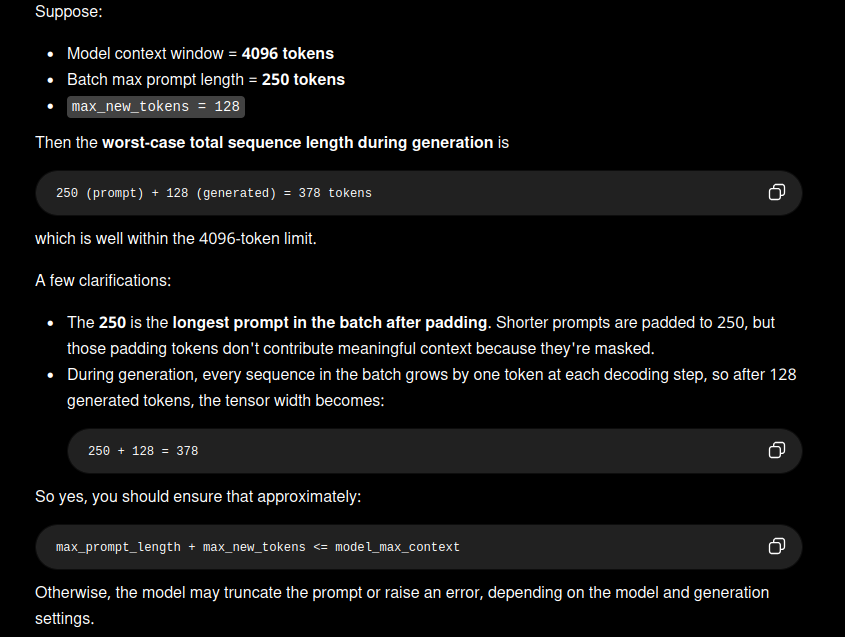

In [25]:
def run_inference(model_id, df, model_label):

    mlflow_start_run(f"Benchmarking {model_label}")


    mlflow.log_params({
            "dataset": DATASET,
            "dataset_expected_len" : EXPECTED_LEN,
            "dataset_sample_size" : SAMPLE_SIZE,
            "dataset_loaded_from_cache" : LOAD_CACHE
        })

    print(f"\n==================================================")
    print(f"=== BENCHMARKING MODEL: {model_label} ===")
    print(f"==================================================")

    # --- CHECKPOINT 1: BASELINE (BEFORE LOADING) ---
    clear_cache()
    gpu_reset_peak()

    base_gpu = gpu_allocated_gb()
    base_cpu = cpu_resident_gb()
    print(f"[Baseline] GPU Allocated: {base_gpu:.3f} GB | CPU Resident: {base_cpu:.3f} GB")

    add_metric(metric_df, "gpu_allocated", "baseline", model_label, base_gpu)
    add_metric(metric_df, "cpu_resident", "baseline", model_label, base_cpu)
    mlflow.log_metric("baseline.gpu_allocated_gb", base_gpu)
    mlflow.log_metric("baseline.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("baseline.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("baseline.cpu_resident_gb", base_cpu)
    mlflow.log_metric("baseline.cpu_virtual_gb", cpu_virtual_gb())
    mlflow.log_metric("baseline.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("baseline.gpu_blindspot_gb", get_gpu_blindspot_gb())

    print(f"\n=== Loading Model: {model_label} ({model_id}) ===")
    
    with BenchmarkTimer() as load_timer:
    # Load tokenizer
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        # Llama 3 models require setting the pad token if it's not set
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        tokenizer.padding_side = "left"
            
        # Load model (Transformers natively supports AWQ if autoawq is installed)
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.float16,
            device_map="auto"
        )


    # --- CHECKPOINT 2: POST-LOAD METRICS ---
    post_load_gpu = gpu_allocated_gb()
    reported_model_size_gb = (post_load_gpu - base_gpu) # Calculated delta via VRAM allocation
    
    print(f"[Loaded] Model Load Time: {load_timer.elapsed:.2f} seconds")
    print(f"[Loaded] Measured Model Weight Size: {reported_model_size_gb:.3f} GB")
    print(f"[Loaded] Current GPU Allocated: {post_load_gpu:.3f} GB | GPU Reserved: {gpu_reserved_gb():.3f} GB")

    add_metric(metric_df, "load_time", "post_load", model_label, load_timer.elapsed)
    add_metric(metric_df, "gpu_allocated", "post_load", model_label, post_load_gpu)
    add_metric(metric_df, "model_size_gb", "post_load", model_label, reported_model_size_gb)

    mlflow.log_metric("post_load.load_time_seconds", load_timer.elapsed)
    mlflow.log_metric("post_load.gpu_allocated_gb", post_load_gpu)
    mlflow.log_metric("post_load.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("post_load.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("post_load.reported_model_size_gb", reported_model_size_gb)
    mlflow.log_metric("post_load.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("post_load.gpu_blindspot_gb", get_gpu_blindspot_gb())

    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    total_size_gb = (param_size + buffer_size) / (1024 ** 3)
    
    
    print(f"-> Model Size in Memory: {total_size_gb:.2f} GB")

    add_metric(metric_df, "model_size_memory_gb", "post_load", model_label, total_size_gb)
    mlflow.log_metric("post_load.model_size_memory_gb", total_size_gb)

    print("\n[Warmup] Initializing CUDA context and JIT kernels...")
    
    # A tiny throwaway prompt
    warmup_messages = [{"role": "user", "content": "Hello."}]
    warmup_prompt = tokenizer.apply_chat_template(
        warmup_messages, tokenize=False, add_generation_prompt=True
    )
    warmup_inputs = tokenizer(warmup_prompt, return_tensors="pt").to(model.device)
    
    # Running fast generation to warm up the GPU and JIT kernels
    with torch.no_grad():
        _ = model.generate(
            **warmup_inputs,
            max_new_tokens=5, 
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
        
    # Synchronize to ensure the GPU has completely finished the warmup task
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    print("[Warmup] Complete. GPU environment is ready.")
    # ---------------------------------------------------------

    # CHECKPOINT : POST WARMUP(BEFORE LOOP) ---
    clear_cache()
    gpu_reset_peak()

    mlflow.log_metric("warmup.gpu_allocated_gb", gpu_allocated_gb() )
    mlflow.log_metric("warmup.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("warmup.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("warmup.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("warmup.gpu_blindspot_gb", get_gpu_blindspot_gb())

    results = []
    latencies = []
    ttft_list = []
    tokens_per_sec_list = []
    itl_list = []
    
    print(f"Running inference on {len(df)} samples...")
    for idx, row in df.iterrows():
        # Format the prompt using Llama 3's chat template for optimal Instruct performance
        messages = [{"role": "user", "content": row["prompt"]}]
        formatted_prompt = tokenizer.apply_chat_template(
            messages, 
            tokenize=False, 
            add_generation_prompt=True
        )
        
        inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)
        
        # Instantiate the custom streamer for this specific prompt
        streamer = TTFTStreamer()
        # Generate text
        with BenchmarkTimer() as inf_timer:
            with torch.no_grad():
                # outputs = model.generate(
                #     **inputs,
                #     max_new_tokens=int(row["expected_len"]),
                #     do_sample=False, # Deterministic greedy decoding for benchmarking
                #     pad_token_id=tokenizer.eos_token_id
                # )
                # Start the TTFT clock exactly when generation starts
                streamer.start_time = time.perf_counter() 
                
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=int(row["expected_len"]),
                    min_new_tokens=int(row["expected_len"]), # Ensure we generate the expected number of tokens for benchmarking
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id,
                    streamer=streamer  
                )
        
        # Decode only the newly generated tokens
        generated_tokens = outputs[0][inputs.input_ids.shape[-1]:]
        num_generated_tokens = len(generated_tokens)

        # If the model fails to generate anything, gracefully handle the NoneType
        ttft_seconds = streamer.ttft if streamer.ttft is not None else 0.0
        ttft_list.append(ttft_seconds)  # Store TTFT for this specific prompt
        # Calculate tokens per second (excluding the TTFT wait time for accuracy)
        generation_time = inf_timer.elapsed - ttft_seconds
        tokens_per_sec = (num_generated_tokens - 1) / generation_time if generation_time > 0 else 0
        itl_seconds = generation_time / (num_generated_tokens - 1)
        # print(f"Inter-Token Latency: {itl_seconds * 1000:.2f} ms")
        # tokens_per_sec = num_generated_tokens / inf_timer.elapsed if inf_timer.elapsed > 0 else 0
        tokens_per_sec_list.append(tokens_per_sec)

        response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
        results.append(response)
        latencies.append(inf_timer.elapsed)
        itl_list.append(itl_seconds)
        
        print(f"[{row['name']}] Done.")

        print(f"  -> [{row['name']}] Generated {num_generated_tokens} tokens in {inf_timer.elapsed:.3f}s ({tokens_per_sec:.2f} tok/s)")

        
 

        
    # --- CHECKPOINT 4: POST-INFERENCE / PEAK ANALYSIS ---
    peak_gpu = gpu_peak_gb()
    print(f"\n[Post-Inference Summary]")
    print(f"[*] Max Peak GPU Memory During Run: {peak_gpu:.3f} GB")
    print(f"[*] Total Execution VRAM Overhead (Peak - Baseline): {peak_gpu - base_gpu:.3f} GB")
    print(f"[*] Average Generation Latency: {sum(latencies)/len(latencies):.3f} seconds")

    add_metric(metric_df, "average_inference_latency", "post_inference", model_label, np.mean(latencies))
    add_metric(metric_df, "average_tokens_per_sec", "post_inference", model_label, np.mean(tokens_per_sec_list))
    add_metric(metric_df, "peak_gpu_allocated", "post_inference", model_label, peak_gpu)

    # mlflow.log_metric("post_inference.warmup_ttft_seconds", ttft_list[0])  # Log the TTFT of the first prompt as a representative warmup metric
    # mlflow.log_metric("post_inference.warmup_inference_latency_seconds", latencies[0])  # Log the latency of the first prompt as a representative warmup metric
    # mlflow.log_metric("post_inference.warmup_tokens_per_sec", tokens_per_sec_list[0])  # Log the tokens per second of the first prompt as a representative warmup metric
    mlflow.log_metric("post_inference.ttft_average_seconds", np.mean(ttft_list[1:]))  # Exclude the first prompt from the average to avoid skewing
    mlflow.log_metric("post_inference.average_inference_latency_seconds", np.mean(latencies[1:]))  # Exclude the first prompt from the average to avoid skewing
    mlflow.log_metric("post_inference.average_tokens_per_sec", np.mean(tokens_per_sec_list[1:]))  # Exclude the first prompt from the average to avoid skewing
    mlflow.log_metric("post_inference.average_inter_token_latency_seconds", np.mean(itl_list[1:]))  # Exclude the first prompt from the average to avoid skewing
    mlflow.log_metric("post_inference.peak_gpu_allocated_gb", peak_gpu)
    mlflow.log_metric("post_inference.total_execution_vram_overhead_gb", peak_gpu - base_gpu)
    mlflow.log_metric("post_inference.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("post_inference.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("post_inference.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("post_inference.gpu_blindspot_gb", get_gpu_blindspot_gb())

    # Clean up GPU memory before the next model loads
    del model
    del tokenizer
    # torch.cuda.empty_cache()
    clear_cache()
    
    final_gpu = gpu_allocated_gb()
    print(f"[Cleanup] Post-Cleanup GPU Allocated: {final_gpu:.3f} GB (Should match or be close to Baseline)")
    add_metric(metric_df, "gpu_allocated", "post_cleanup", model_label, final_gpu)
    mlflow.log_metric("post_cleanup.gpu_allocated_gb", final_gpu)
    mlflow.log_metric("post_cleanup.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("post_cleanup.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("post_cleanup.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("post_cleanup.gpu_blindspot_gb", get_gpu_blindspot_gb())

    print(f"\n=== Finished Benchmarking Model: {model_label} ===\n")
    print(f"==================================================\n")
    print(f"=== METRICS DATAFRAME ===")
    print(metric_df)

    return results

## Batch Inference Definition

In [31]:
def run_batch_inference(model_id, df, model_label, batch_size=2):

    mlflow_start_run(f"Benchmarking {model_label}")


    mlflow.log_params({
            "dataset": DATASET,
            "dataset_expected_len" : EXPECTED_LEN,
            "dataset_sample_size" : SAMPLE_SIZE,
            "dataset_loaded_from_cache" : LOAD_CACHE
        })


    print(f"\n==================================================")
    print(f"=== BENCHMARKING MODEL: {model_label} ===")
    print(f"==================================================")

    # --- CHECKPOINT 1: BASELINE (BEFORE LOADING) ---
    clear_cache()
    gpu_reset_peak()

    base_gpu = gpu_allocated_gb()
    base_cpu = cpu_resident_gb()
    print(f"[Baseline] GPU Allocated: {base_gpu:.3f} GB | CPU Resident: {base_cpu:.3f} GB")

    add_metric(metric_df, "gpu_allocated", "baseline", model_label, base_gpu)
    add_metric(metric_df, "cpu_resident", "baseline", model_label, base_cpu)
    mlflow.log_metric("baseline.gpu_allocated_gb", base_gpu)
    mlflow.log_metric("baseline.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("baseline.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("baseline.cpu_resident_gb", base_cpu)
    mlflow.log_metric("baseline.cpu_virtual_gb", cpu_virtual_gb())
    mlflow.log_metric("baseline.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("baseline.gpu_blindspot_gb", get_gpu_blindspot_gb())

    print(f"\n=== Loading Model: {model_label} ({model_id}) ===")
    
    with BenchmarkTimer() as load_timer:
    # Load tokenizer
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        # Llama 3 models require setting the pad token if it's not set
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        tokenizer.padding_side = "left"
            
        # Load model (Transformers natively supports AWQ if autoawq is installed)
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.float16,
            device_map="auto"
        )


    # --- CHECKPOINT 2: POST-LOAD METRICS ---
    post_load_gpu = gpu_allocated_gb()
    reported_model_size_gb = (post_load_gpu - base_gpu) # Calculated delta via VRAM allocation
    
    print(f"[Loaded] Model Load Time: {load_timer.elapsed:.2f} seconds")
    print(f"[Loaded] Measured Model Weight Size: {reported_model_size_gb:.3f} GB")
    print(f"[Loaded] Current GPU Allocated: {post_load_gpu:.3f} GB | GPU Reserved: {gpu_reserved_gb():.3f} GB")

    add_metric(metric_df, "load_time", "post_load", model_label, load_timer.elapsed)
    add_metric(metric_df, "gpu_allocated", "post_load", model_label, post_load_gpu)
    add_metric(metric_df, "model_size_gb", "post_load", model_label, reported_model_size_gb)

    mlflow.log_metric("post_load.load_time_seconds", load_timer.elapsed)
    mlflow.log_metric("post_load.gpu_allocated_gb", post_load_gpu)
    mlflow.log_metric("post_load.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("post_load.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("post_load.reported_model_size_gb", reported_model_size_gb)
    mlflow.log_metric("post_load.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("post_load.gpu_blindspot_gb", get_gpu_blindspot_gb())

    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    total_size_gb = (param_size + buffer_size) / (1024 ** 3)
    
    
    print(f"-> Model Size in Memory: {total_size_gb:.2f} GB")

    add_metric(metric_df, "model_size_memory_gb", "post_load", model_label, total_size_gb)
    mlflow.log_metric("post_load.model_size_memory_gb", total_size_gb)

    print("\n[Warmup] Initializing CUDA context and JIT kernels...")
    
    # A tiny throwaway prompt
    warmup_messages = [{"role": "user", "content": "Hello."}]
    warmup_prompt = tokenizer.apply_chat_template(
        warmup_messages, tokenize=False, add_generation_prompt=True
    )
    warmup_inputs = tokenizer(warmup_prompt, return_tensors="pt").to(model.device)
    
    # Running fast generation to warm up the GPU and JIT kernels
    with torch.no_grad():
        _ = model.generate(
            **warmup_inputs,
            max_new_tokens=5, 
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
        
    # Synchronize to ensure the GPU has completely finished the warmup task
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    print("[Warmup] Complete. GPU environment is ready.")
    # ---------------------------------------------------------

    # CHECKPOINT : POST WARMUP(BEFORE LOOP) ---
    clear_cache()
    gpu_reset_peak()

    mlflow.log_metric("warmup.gpu_allocated_gb", gpu_allocated_gb() )
    mlflow.log_metric("warmup.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("warmup.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("warmup.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("warmup.gpu_blindspot_gb", get_gpu_blindspot_gb())

    results = []
    latencies = []
    ttft_list = []
    tokens_per_sec_list = []
    itl_list = []
    system_tps_list = []
    efficiency_ratio_list = []
    padding_tax_list = []
    query_tokens_list = []
    completion_tokens_list = []
    avg_compute_list = []
    max_compute_list = []
    oom_exception = 0
    other_exception = 0
    
    print(f"Running inference on {len(df)} samples...")
   
    batch = 1
    # Chunk the dataframe into batches
    for i in range(0, len(df), batch_size):
        batch_df = df.iloc[i : i + batch_size]

        batch += 1
        
        
        # 1. Format the batch of prompts
        formatted_prompts = []
        for prompt in batch_df["prompt"]:
            messages = [{"role": "user", "content": prompt}]
            formatted = tokenizer.apply_chat_template(
                messages, 
                tokenize=False, ## we are returning plain text not as token IDs
                add_generation_prompt=True
            )
            formatted_prompts.append(formatted) ## a list of formatted prompt strings

        ## here we are converting to something like this
        # <|begin_of_text|>
        #     <|start_header_id|>
        #     user
        #     <|end_header_id|>
        #     What is quantum computing?
        # <|eot_id|>
        #     <|start_header_id|>
        #     assistant
        #     <|end_header_id|>
        
        # 2. Tokenize the batch with padding
        inputs = tokenizer(
            formatted_prompts, 
            return_tensors="pt", 
            padding=True,       # Pad to the longest sequence in the batch
            truncation=True     # Optional: protect against exceeding max context
        ).to(model.device)
        
        # Result is a dict like object containing tokens tensor (Batch_Size x Max Seq Length) / attentions mask (Batch_Size x Max Seq Length)

        # 3. Reconcile expected lengths for the batch
        # model.generate only accepts a single integer for max/min_new_tokens
        # We must use the maximum expected length within this specific batch
        batch_max_len = int(batch_df["expected_len"].max())
        
        streamer = TTFTStreamer()
        try:
        # 4. Generate text
            # with BenchmarkTimer() as inf_timer:
            with BenchmarkTimer() as inf_timer, AsyncGPUMonitor(device_index=0) as gpu_monitor:
                with torch.no_grad():
                    streamer.start_time = time.perf_counter() 
                    
                    outputs = model.generate(
                        **inputs,  # This passes input_ids AND attention_mask
                        max_new_tokens=batch_max_len,
                        min_new_tokens=batch_max_len, 
                        do_sample=False,
                        pad_token_id=tokenizer.eos_token_id,
                        streamer=streamer  
                    )

            avg_compute, max_compute = gpu_monitor.get_metrics()
            avg_compute_list.append(avg_compute)
            max_compute_list.append(max_compute)
        except torch.cuda.OutOfMemoryError as e:
            print(f"\n[WARNING] CUDA Out of Memory Error caught!")
            # print(f"OOM triggered at expected length: {batch_max_len}.")
            print("Clearing CUDA cache and breaking out of the loop to save collected metrics...")
            oom_exception = 1
            # torch.cuda.empty_cache()
            break

        except Exception as e:
            print(f"\n[WARNING] Exception Caught : {e}")
            # print(f"OOM triggered at expected length: {batch_max_len}.")
            print("Clearing CUDA cache and breaking out of the loop to save collected metrics...")
            # torch.cuda.empty_cache()
            other_exception = 1
            break


        # The streamer captures TTFT for the whole batch simultaneously
        ttft_seconds = streamer.ttft if streamer.ttft is not None else 0.0
        input_len = inputs.input_ids.shape[-1]
        # tokens_generated_per_sequence = outputs.shape[-1] - input_len
        # total_compute_tokens = len(outputs) * tokens_generated_per_sequence
        total_output_len = outputs.shape[-1] 
        total_compute_tokens = len(outputs) * total_output_len
        print(f"Batch {i} : total compute tokens - {total_compute_tokens}")
        total_useful_tokens = 0
        # Iterate through every output sequence in the current batch
        for i in range(len(outputs)):

            query_tokens = inputs.attention_mask[i].sum().item()
            # 1. Slice only the newly generated tokens
            # inputs.input_ids[i] gives us the exact length of the padded input prompt
            input_len = inputs.input_ids[i].shape[-1]
            raw_generated_tokens = outputs[i][input_len:]
            
            # 2. Strip padding/EOS tokens so they don't artificially inflate throughput
            actual_tokens = [
                tok for tok in raw_generated_tokens 
                if tok != tokenizer.pad_token_id and tok != tokenizer.eos_token_id
            ]

            completion_tokens = len(actual_tokens)
            num_generated_tokens = len(actual_tokens)
            # total_useful_tokens += num_generated_tokens
            total_useful_tokens += (query_tokens + num_generated_tokens)
            print(f"=>Seq {i} : query token-{query_tokens} | input len-{input_len} | raw tokens-{len(raw_generated_tokens)} | actual tokens-{len(actual_tokens)} | total useful tokens-{total_useful_tokens}")
            # 3. Calculate metrics
            generation_time = inf_timer.elapsed - ttft_seconds
            
            if generation_time > 0 and num_generated_tokens > 1:
                tokens_per_sec = (num_generated_tokens - 1) / generation_time
                itl_seconds = generation_time / (num_generated_tokens - 1)
            else:
                tokens_per_sec = 0
                itl_seconds = 0
            
            # 4. Decode the clean response
            response = tokenizer.decode(actual_tokens, skip_special_tokens=True)
            
            # 5. Append to your master tracking lists
            results.append(response)
            ttft_list.append(ttft_seconds)
            latencies.append(inf_timer.elapsed)  # The time the whole batch took
            itl_list.append(itl_seconds)
            tokens_per_sec_list.append(tokens_per_sec)
            query_tokens_list.append(query_tokens)
            completion_tokens_list.append(completion_tokens)
        
        # print(f"[{row['name']}] Done.")

        # print(f"  -> [{row['name']}] Generated {num_generated_tokens} tokens in {inf_timer.elapsed:.3f}s ({tokens_per_sec:.2f} tok/s)")
        # total_batch_tokens = sum(
        #     len([t for t in outputs[i][inputs.input_ids[i].shape[-1]:] if t not in (tokenizer.pad_token_id, tokenizer.eos_token_id)])
        #     for i in range(len(outputs))
        # )

        wasted_tokens = total_compute_tokens - total_useful_tokens
        efficiency_ratio = (total_useful_tokens / total_compute_tokens) * 100 if total_compute_tokens > 0 else 0
        padding_tax = (wasted_tokens / total_compute_tokens) * 100



        # system_tps = total_batch_tokens / inf_timer.elapsed
        system_tps = total_useful_tokens / inf_timer.elapsed
        print(f"Batch System Throughput: {system_tps:.2f} tokens/sec | Efficency Ratio : {efficiency_ratio:.2f} | Padding Tax : {padding_tax:.2f}")
        
        system_tps_list.append(system_tps)
        efficiency_ratio_list.append(efficiency_ratio)
        padding_tax_list.append(padding_tax)

        # batch wise metrics
        mlflow.log_metric("batch_inference.batch_avg_ttft_seconds", np.mean(ttft_list),step=batch)  # Exclude the first prompt from the average to avoid skewing
        mlflow.log_metric("batch_inference.batch_avg_inference_latency_seconds", np.mean(latencies),step=batch)  # Exclude the first prompt from the average to avoid skewing
        mlflow.log_metric("batch_inference.batch_avg_tokens_per_sec", np.mean(tokens_per_sec_list),step=batch)  # Exclude the first prompt from the average to avoid skewing
        mlflow.log_metric("batch_inference.batch_avg_inter_token_latency_seconds", np.mean(itl_list),step=batch)  # Exclude the first prompt from the average to avoid skewing
        mlflow.log_metric("batch_inference.batch_avg_system_throughput_tokens_per_sec", np.mean(system_tps_list),step=batch)  # Exclude the first batch from the average to avoid skewing
        mlflow.log_metric("batch_inference.batch_avg_efficiency_ratio",np.mean(efficiency_ratio_list),step=batch)
        mlflow.log_metric("batch_inference.batch_max_efficiency_ratio",np.max(efficiency_ratio_list),step=batch)
        mlflow.log_metric("batch_inference.batch_avg_padding_tax",np.mean(padding_tax_list),step=batch)
        mlflow.log_metric("batch_inference.batch_max_padding_tax",np.max(padding_tax_list),step=batch)
        mlflow.log_metric("batch_inference.batch_avg_query_tokens", np.mean(query_tokens_list),step=batch)
        mlflow.log_metric("batch_inference.batch_avg_completion_tokens", np.mean(completion_tokens_list),step=batch)
        mlflow.log_metric("batch_inference.batch_max_query_tokens", np.max(query_tokens_list),step=batch)
        mlflow.log_metric("batch_inference.batch_max_completion_tokens", np.max(completion_tokens_list),step=batch)
        mlflow.log_metric("batch_inference.batch_peak_gpu_allocated_gb", gpu_peak_gb(),step=batch)
        mlflow.log_metric("batch_inference.batch_total_execution_vram_overhead_gb", gpu_peak_gb() - gpu_allocated_gb(),step=batch)
        mlflow.log_metric("batch_inference.batch_gpu_reserved_gb", gpu_reserved_gb(),step=batch)
        mlflow.log_metric("batch_inference.batch_gpu_peak_reserved_gb", gpu_peak_reserved_gb(),step=batch)
        mlflow.log_metric("batch_inference.batch_gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage(),step=batch)
        mlflow.log_metric("batch_inference.batch_gpu_blindspot_gb", get_gpu_blindspot_gb(),step=batch)
        mlflow.log_metric("batch_inference.batch_gpu_avg_compute",avg_compute,step=batch)
        mlflow.log_metric("batch_inference.batch_gpu_max_compute",max_compute,step=batch)

 

        
    # --- CHECKPOINT 4: POST-INFERENCE / PEAK ANALYSIS ---
    peak_gpu = gpu_peak_gb()
    print(f"\n[Post-Inference Summary]")
    print(f"[*] Max Peak GPU Memory During Run: {peak_gpu:.3f} GB")
    print(f"[*] Total Execution VRAM Overhead (Peak - Baseline): {peak_gpu - base_gpu:.3f} GB")
    print(f"[*] Average Generation Latency: {sum(latencies)/len(latencies):.3f} seconds")

    add_metric(metric_df, "average_inference_latency", "post_inference", model_label, np.mean(latencies))
    add_metric(metric_df, "average_tokens_per_sec", "post_inference", model_label, np.mean(tokens_per_sec_list))
    add_metric(metric_df, "peak_gpu_allocated", "post_inference", model_label, peak_gpu)

    # mlflow.log_metric("post_inference.warmup_ttft_seconds", ttft_list[0])  # Log the TTFT of the first prompt as a representative warmup metric
    # mlflow.log_metric("post_inference.warmup_inference_latency_seconds", latencies[0])  # Log the latency of the first prompt as a representative warmup metric
    # mlflow.log_metric("post_inference.warmup_tokens_per_sec", tokens_per_sec_list[0])  # Log the tokens per second of the first prompt as a representative warmup metric
    mlflow.log_metric("post_inference.ttft_average_seconds", np.mean(ttft_list[1:]))  # Exclude the first prompt from the average to avoid skewing
    mlflow.log_metric("post_inference.average_inference_latency_seconds", np.mean(latencies[1:]))  # Exclude the first prompt from the average to avoid skewing
    mlflow.log_metric("post_inference.average_tokens_per_sec", np.mean(tokens_per_sec_list[1:]))  # Exclude the first prompt from the average to avoid skewing
    mlflow.log_metric("post_inference.average_inter_token_latency_seconds", np.mean(itl_list[1:]))  # Exclude the first prompt from the average to avoid skewing
    mlflow.log_metric("post_inference.average_system_throughput_tokens_per_sec", np.mean(system_tps_list[1:]))  # Exclude the first batch from the average to avoid skewing
    mlflow.log_metric("post_inference.average_efficiency_ratio",np.mean(efficiency_ratio_list[1:]))
    mlflow.log_metric("post_inference.max_efficiency_ratio",np.max(efficiency_ratio_list[1:]))
    mlflow.log_metric("post_inference.average_padding_tax",np.mean(padding_tax_list[1:]))
    mlflow.log_metric("post_inference.max_padding_tax",np.max(padding_tax_list[1:]))
    mlflow.log_metric("post_inference.average_query_tokens", np.mean(query_tokens_list))
    mlflow.log_metric("post_inference.average_completion_tokens", np.mean(completion_tokens_list))
    mlflow.log_metric("post_inference.max_query_tokens", np.max(query_tokens_list))
    mlflow.log_metric("post_inference.max_completion_tokens", np.max(completion_tokens_list))
    mlflow.log_metric("post_inference.peak_gpu_allocated_gb", peak_gpu)
    mlflow.log_metric("post_inference.total_execution_vram_overhead_gb", peak_gpu - base_gpu)
    mlflow.log_metric("post_inference.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("post_inference.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("post_inference.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("post_inference.gpu_blindspot_gb", get_gpu_blindspot_gb())
    mlflow.log_metric("post_inference.gpu_avg_compute",np.mean(avg_compute_list),step=batch)
    mlflow.log_metric("post_inference.gpu_max_compute",np.max(max_compute_list),step=batch)
    mlflow.log_metric("post_inference.oom_exception",oom_exception)
    mlflow.log_metric("post_inference.other_exception",other_exception)

    # Clean up GPU memory before the next model loads
    del model
    del tokenizer
    # torch.cuda.empty_cache()
    clear_cache()
    
    final_gpu = gpu_allocated_gb()
    print(f"[Cleanup] Post-Cleanup GPU Allocated: {final_gpu:.3f} GB (Should match or be close to Baseline)")
    add_metric(metric_df, "gpu_allocated", "post_cleanup", model_label, final_gpu)
    mlflow.log_metric("post_cleanup.gpu_allocated_gb", final_gpu)
    mlflow.log_metric("post_cleanup.gpu_reserved_gb", gpu_reserved_gb())
    mlflow.log_metric("post_cleanup.gpu_peak_reserved_gb", gpu_peak_reserved_gb())
    mlflow.log_metric("post_cleanup.gpu_absolute_memory_usage_gb", get_gpu_absolute_memory_usage())
    mlflow.log_metric("post_cleanup.gpu_blindspot_gb", get_gpu_blindspot_gb())

    print(f"\n=== Finished Benchmarking Model: {model_label} ===\n")
    print(f"==================================================\n")
    print(f"=== METRICS DATAFRAME ===")
    print(metric_df)

    return results

## Dataset

In [27]:
type(dataset)

pandas.core.frame.DataFrame

In [28]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          128 non-null    object
 1   prompt        128 non-null    object
 2   expected_len  128 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 3.1+ KB


In [29]:
dataset['expected_len']

0       13
1       14
2       16
3       22
4       24
      ... 
123    627
124    633
125    662
126    700
127    767
Name: expected_len, Length: 128, dtype: int64

## FP16 Baseline Run

In [44]:

dataset["response_fp16"] = run_inference(MODEL_FP16, dataset, "LLAMA_3_2_3B_FP16")

🏃 View run Benchmarking LLAMA_3_2_3B_FP16_BATCH_SIZE_8 at: http://localhost:5000/#/experiments/6/runs/78c5dc2690b24db49009d5652a473c05
🧪 View experiment at: http://localhost:5000/#/experiments/6

=== BENCHMARKING MODEL: LLAMA_3_2_3B_FP16 ===
[Baseline] GPU Allocated: 0.008 GB | CPU Resident: 4.706 GB

=== Loading Model: LLAMA_3_2_3B_FP16 (meta-llama/Llama-3.2-3B-Instruct) ===


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

[Loaded] Model Load Time: 3.18 seconds
[Loaded] Measured Model Weight Size: 5.984 GB
[Loaded] Current GPU Allocated: 5.992 GB | GPU Reserved: 6.010 GB
-> Model Size in Memory: 5.98 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...
[sharegpt_QWJhYvA_0] Done.
  -> [sharegpt_QWJhYvA_0] Generated 256 tokens in 2.891s (88.70 tok/s)
[sharegpt_i6IyJda_0] Done.
  -> [sharegpt_i6IyJda_0] Generated 256 tokens in 2.881s (88.92 tok/s)
[sharegpt_A5AbcES_0] Done.
  -> [sharegpt_A5AbcES_0] Generated 256 tokens in 2.892s (88.65 tok/s)
[sharegpt_hRPPgZT_0] Done.
  -> [sharegpt_hRPPgZT_0] Generated 256 tokens in 2.895s (88.57 tok/s)
[sharegpt_IWkMGRK_0] Done.
  -> [sharegpt_IWkMGRK_0] Generated 256 tokens in 2.917s (88.21 tok/s)
[sharegpt_yn2eWCt_0] Done.
  -> [sharegpt_yn2eWCt_0] Generated 256 tokens in 2.878s (89.05 tok/s)
[sharegpt_DhelrJT_0] Done.
  -> [sharegpt_DhelrJT_0] Generated 256 tokens in 2.847s (90.00 t

## FP16 Baseline Batch Run

### Batch Size 1

In [30]:
dataset["response_fp16"] = run_batch_inference(MODEL_FP16, dataset, f"LLAMA_3_2_3B_FP16_BATCH_SIZE_1_{EXPECTED_LEN}_LEN", batch_size=1)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_FP16_BATCH_SIZE_1_DYNAMIC_LEN ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.958 GB

=== Loading Model: LLAMA_3_2_3B_FP16_BATCH_SIZE_1_DYNAMIC_LEN (meta-llama/Llama-3.2-3B-Instruct) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

[Loaded] Model Load Time: 3.57 seconds
[Loaded] Measured Model Weight Size: 5.984 GB
[Loaded] Current GPU Allocated: 5.984 GB | GPU Reserved: 6.004 GB
-> Model Size in Memory: 5.98 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch 0 : total compute tokens - 13
=>Seq 0 : query token-44 | input len-44 | raw tokens-13 | actual tokens-13 | total useful tokens-13
Batch System Throughput: 64.31 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch 1 : total compute tokens - 14
=>Seq 0 : query token-59 | input len-59 | raw tokens-14 | actual tokens-14 | total useful tokens-14
Batch System Throughput: 69.56 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch 2 : total compute tokens - 16
=>Seq 0 : query token-147 | input len-147 | raw tokens-16 | actual tokens-16 | total useful tokens-16
Batch System Throughput: 79.43 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch 3 : total compute tokens - 22
=>Seq 0 : query token-1117 | input len-1117 | raw tokens-22 | actual tokens-22 | total useful tokens-22
Batch System Throughput: 54.84 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch 4 : total compute tokens - 24
=>Seq 0 : query token-60 | input len-60 | raw tokens-2

KeyboardInterrupt: 

In [68]:
dataset['word_count'] = dataset['response_fp16'].str.split().str.len()

In [69]:
dataset

,name,prompt,expected_len,response_fp16,word_count
0,sharegpt_Ot1oxuK_0,Rewrite the following script in C++,13,I don't see a script provided. Please provide ...,11
1,sharegpt_LINiOhS_0,"Hi, i will give you three pieces of text, then...",14,"You'll provide three pieces of text, and then ...",11
2,sharegpt_6TbIqut_0,#ifndef DATA\_HPP\n#define DATA\_HPP\n\n#inclu...,16,It looks like you're writing a C++ class for a...,13
3,sharegpt_LINiOhS_8,Here is Text 3: Diversity and Intercultural Co...,22,I'm ready to answer questions about Text 3: Di...,16
4,sharegpt_X1NXUxZ_0,Hello friend. My task for today is to engage i...,24,I'd be delighted to engage in a debate with yo...,20
...,...,...,...,...,...
123,sharegpt_otSTSpB_0,Provide a detailed chronology of the Apostle J...,627,The Apostle John is one of the most prominent ...,388
124,sharegpt_aureXq6_0,write an essay on french revolution,633,The French Revolution was a pivotal event in m...,499
125,sharegpt_ng7rjf6_0,explane more,662,It seems like you didn't specify what you'd li...,473
126,sharegpt_6Zoa7wI_0,Implement my own netfilter in linux with linux...,700,Implementing a full-fledged netfilter in Rust ...,365


### Batch Size 2

In [30]:
dataset["response_fp16"] = run_batch_inference(MODEL_FP16, dataset, f"LLAMA_3_2_3B_FP16_BATCH_SIZE_2_{EXPECTED_LEN}_LEN", batch_size=2)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_FP16_BATCH_SIZE_2_DYNAMIC_LEN ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.958 GB

=== Loading Model: LLAMA_3_2_3B_FP16_BATCH_SIZE_2_DYNAMIC_LEN (meta-llama/Llama-3.2-3B-Instruct) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

[Loaded] Model Load Time: 3.79 seconds
[Loaded] Measured Model Weight Size: 5.984 GB
[Loaded] Current GPU Allocated: 5.984 GB | GPU Reserved: 6.004 GB
-> Model Size in Memory: 5.98 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch 0 : total compute tokens - 28
=>Seq 0 : query token-44 | input len-59 | raw tokens-14 | actual tokens-14 | total useful tokens-14
=>Seq 1 : query token-59 | input len-59 | raw tokens-14 | actual tokens-14 | total useful tokens-28
Batch System Throughput: 92.70 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch 2 : total compute tokens - 44
=>Seq 0 : query token-147 | input len-1117 | raw tokens-22 | actual tokens-22 | total useful tokens-22
=>Seq 1 : query token-1117 | input len-1117 | raw tokens-22 | actual tokens-22 | total useful tokens-44
Batch System Throughput: 73.15 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch 4 : total compute tokens - 48
=>Seq 0 : query token-60 | input len-60 | raw tokens-24 | actual tokens-24 | total useful tokens-24
=>Seq 1 : query token-40 | input len-60 | raw tokens-24 | actual tokens-24 | total useful tokens-48
Batch System Throughput: 119.58 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch 6 : tota

### Batch Size 4

In [ ]:
dataset["response_fp16"] = run_batch_inference(MODEL_FP16, dataset, f"LLAMA_3_2_3B_FP16_BATCH_SIZE_4_{EXPECTED_LEN}_LEN", batch_size=4)

🏃 View run Benchmarking LLAMA_3_2_3B_FP16_BATCH_SIZE_2 at: http://localhost:5000/#/experiments/6/runs/58dedf9c1d6f48be846df5503e701610
🧪 View experiment at: http://localhost:5000/#/experiments/6

=== BENCHMARKING MODEL: LLAMA_3_2_3B_FP16_BATCH_SIZE_4 ===
[Baseline] GPU Allocated: 0.008 GB | CPU Resident: 2.201 GB

=== Loading Model: LLAMA_3_2_3B_FP16_BATCH_SIZE_4 (meta-llama/Llama-3.2-3B-Instruct) ===


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

[Loaded] Model Load Time: 3.17 seconds
[Loaded] Measured Model Weight Size: 5.984 GB
[Loaded] Current GPU Allocated: 5.992 GB | GPU Reserved: 6.010 GB
-> Model Size in Memory: 5.98 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...
Batch System Throughput: 269.16 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 243.55 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 276.47 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 243.56 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 112.41 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 140.14 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 182.59 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 284.14 tokens/sec 

### Batch Size 8

In [ ]:
dataset["response_fp16"] = run_batch_inference(MODEL_FP16, dataset, f"LLAMA_3_2_3B_FP16_BATCH_SIZE_8_{EXPECTED_LEN}_LEN", batch_size=8)

🏃 View run Benchmarking LLAMA_3_2_3B_FP16_BATCH_SIZE_4 at: http://localhost:5000/#/experiments/6/runs/c8271e6c3daa4640915abc098aae52ca
🧪 View experiment at: http://localhost:5000/#/experiments/6

=== BENCHMARKING MODEL: LLAMA_3_2_3B_FP16_BATCH_SIZE_8 ===
[Baseline] GPU Allocated: 0.008 GB | CPU Resident: 2.485 GB

=== Loading Model: LLAMA_3_2_3B_FP16_BATCH_SIZE_8 (meta-llama/Llama-3.2-3B-Instruct) ===


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

[Loaded] Model Load Time: 3.18 seconds
[Loaded] Measured Model Weight Size: 5.984 GB
[Loaded] Current GPU Allocated: 5.992 GB | GPU Reserved: 6.010 GB
-> Model Size in Memory: 5.98 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...
Batch System Throughput: 435.32 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 409.15 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 144.11 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 269.20 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 393.46 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 142.11 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 176.41 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 258.98 tokens/sec 

ValueError: Length of values (112) does not match length of index (128)

## AWQ Run

In [17]:
dataset["response_awq"] = run_inference(MODEL_AWQ, dataset, "LLAMA_3_2_3B_AWQ_CUSTOM")


=== BENCHMARKING MODEL: LLAMA_3_2_3B_AWQ_CUSTOM ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.937 GB

=== Loading Model: LLAMA_3_2_3B_AWQ_CUSTOM (./models/llama-3.2-3b-instruct-awq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

Loading weights:   0%|          | 0/646 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 5808 objects in 0.235s                            


[Loaded] Model Load Time: 4.56 seconds
[Loaded] Measured Model Weight Size: 2.098 GB
[Loaded] Current GPU Allocated: 2.098 GB | GPU Reserved: 2.152 GB
-> Model Size in Memory: 2.10 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 10 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[simple_qa_1] Done.
  -> [simple_qa_1] Generated 32 tokens in 0.321s (102.64 tok/s)
[simple_qa_2] Done.
  -> [simple_qa_2] Generated 32 tokens in 0.318s (101.06 tok/s)
[reasoning_1] Done.
  -> [reasoning_1] Generated 128 tokens in 1.257s (101.99 tok/s)
[reasoning_2] Done.
  -> [reasoning_2] Generated 128 tokens in 1.268s (101.23 tok/s)
[coding_1] Done.
  -> [coding_1] Generated 200 tokens in 1.939s (103.23 tok/s)
[coding_2] Done.
  -> [coding_2] Generated 128 tokens in 1.241s (103.34 tok/s)
[summarization] Done.
  -> [summarization] Generated 64 tokens in 0.628s (102.68 tok/s)
[long_context] Done.
  -> [long_context] Generated 96 tokens in 0.954s (101.42 tok/s)
[math_1] Done.
  -> [math_1] Generated 96 tokens in 0.928s (103.61 tok/s)
[math_2] Done.
  -> [math_2] Generated 64 tokens in 0.618s (103.96 tok/s)

[Post-Inference Summary]
[*] Max Peak GPU Memory During Run: 2.136 GB
[*] Total Execution VRAM Overhead (Peak - Baseline): 2.136 GB
[*] Average Generation Latency: 0.947 seconds
[Cl

### AWQ Inference Run Batch Size = 1 

In [41]:
dataset["response_awq"] = run_batch_inference(MODEL_AWQ, dataset, "LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_1",batch_size=1)

🏃 View run Benchmarking LLAMA_3_2_3B_FP16_BATCH_SIZE_8 at: http://localhost:5000/#/experiments/6/runs/0b788b3e76194fda8c7f6a3a20612439
🧪 View experiment at: http://localhost:5000/#/experiments/6

=== BENCHMARKING MODEL: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_1 ===
[Baseline] GPU Allocated: 0.008 GB | CPU Resident: 2.899 GB

=== Loading Model: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_1 (./models/llama-3.2-3b-instruct-awq-custom) ===



WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


INFO  

┌─────────────┐    ┌────────────────────────┐    ┌────────────┐    ┌─────────┐
│ GPT-QModel  │ -> │ ▓▓▓▓▓▓▓▓▓▓▓▓ 16bit     │ -> │ ▒▒▒▒ 8bit  │ -> │ ░░ 4bit │
└─────────────┘    └────────────────────────┘    └────────────┘    └─────────┘
GPT-QModel   : 7.1.0+0eb56c9
Transformers : 5.12.1
Torch        : 2.11.0+cu130
Triton       : 3.6.0


INFO  Kernel: Auto-selection: adding candidate `AwqMarlinLinear`               


INFO  Kernel: selected -> `AwqMarlinLinear`.                                   


Loading weights:   0%|          | 0/646 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 5847 objects in 0.271s                            


[Loaded] Model Load Time: 4.03 seconds
[Loaded] Measured Model Weight Size: 2.098 GB
[Loaded] Current GPU Allocated: 2.106 GB | GPU Reserved: 2.160 GB
-> Model Size in Memory: 2.10 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...
Batch System Throughput: 94.69 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 91.31 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 91.30 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 91.30 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 91.31 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 94.70 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 91.31 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 91.30 tokens/sec | Effice

### AWQ Inference Run Batch Size = 2

In [27]:
dataset["response_awq"] = run_batch_inference(MODEL_AWQ, dataset, "LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_2",batch_size=2)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_2 ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.959 GB

=== Loading Model: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_2 (./models/llama-3.2-3b-instruct-awq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

Loading weights:   0%|          | 0/646 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 5787 objects in 0.255s                            


[Loaded] Model Load Time: 3.03 seconds
[Loaded] Measured Model Weight Size: 2.098 GB
[Loaded] Current GPU Allocated: 2.098 GB | GPU Reserved: 2.150 GB
-> Model Size in Memory: 2.10 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch System Throughput: 164.90 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 164.94 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 159.79 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 164.92 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 159.79 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 164.95 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 164.94 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 159.80 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 118.89 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 102.29 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 127.85 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00

### AWQ Inference Run Batch Size = 4

In [27]:
dataset["response_awq"] = run_batch_inference(MODEL_AWQ, dataset, "LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_4",batch_size=4)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_4 ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.955 GB

=== Loading Model: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_4 (./models/llama-3.2-3b-instruct-awq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

Loading weights:   0%|          | 0/646 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 5787 objects in 0.252s                            


[Loaded] Model Load Time: 3.00 seconds
[Loaded] Measured Model Weight Size: 2.098 GB
[Loaded] Current GPU Allocated: 2.098 GB | GPU Reserved: 2.150 GB
-> Model Size in Memory: 2.10 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch System Throughput: 329.80 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 319.59 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 319.57 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 309.89 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 124.74 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 159.82 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 232.45 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 319.58 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 309.90 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 319.57 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 319.58 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00

### AWQ Inference Run Batch Size = 8

In [27]:
dataset["response_awq"] = run_batch_inference(MODEL_AWQ, dataset, "LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_8",batch_size=8)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_8 ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.957 GB

=== Loading Model: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_8 (./models/llama-3.2-3b-instruct-awq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

Loading weights:   0%|          | 0/646 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 5787 objects in 0.245s                            


[Loaded] Model Load Time: 3.06 seconds
[Loaded] Measured Model Weight Size: 2.098 GB
[Loaded] Current GPU Allocated: 2.098 GB | GPU Reserved: 2.152 GB
-> Model Size in Memory: 2.10 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch System Throughput: 568.15 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 538.35 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 153.83 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 309.96 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 498.94 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 148.25 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 187.70 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 296.50 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 639.13 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 639.17 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 552.81 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00

### AWQ Inference Run Batch Size = 16

In [27]:
dataset["response_awq"] = run_batch_inference(MODEL_AWQ, dataset, "LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_16",batch_size=16)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_16 ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.958 GB

=== Loading Model: LLAMA_3_2_3B_AWQ_CUSTOM_BATCH_SIZE_16 (./models/llama-3.2-3b-instruct-awq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

INFO  gc.collect() reclaimed 5787 objects in 0.252s                            


[Loaded] Model Load Time: 3.09 seconds
[Loaded] Measured Model Weight Size: 2.098 GB
[Loaded] Current GPU Allocated: 2.098 GB | GPU Reserved: 2.152 GB
-> Model Size in Memory: 2.10 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch System Throughput: 717.54 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 173.40 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 167.71 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 216.52 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 1076.52 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 639.32 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 217.67 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00

[WARNING] CUDA Out of Memory Error caught!
Clearing CUDA cache and breaking out of the loop to save collected metrics...

[Post-Inference Summary]
[*] Max Peak GPU Memory During Run: 12.007 GB
[*] Total Execution VRAM Overhead (Peak - Baseline): 12.007 GB
[*] Average Generation Latency: 14.529 seconds
[Cleanup] Post-Cleanup GPU Allocated: 2.108 GB (Should mat

ValueError: Length of values (112) does not match length of index (128)

## GPTQ Run

In [17]:
dataset["response_gptq"] = run_inference(MODEL_GPTQ, dataset, "LLAMA_3_2_3B_GPTQ_CUSTOM")


=== BENCHMARKING MODEL: LLAMA_3_2_3B_GPTQ_CUSTOM ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.937 GB

=== Loading Model: LLAMA_3_2_3B_GPTQ_CUSTOM (./models/llama-3.2-3b-instruct-gptq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

Loading weights:   0%|          | 0/842 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 120 objects in 0.234s                             


[Loaded] Model Load Time: 4.30 seconds
[Loaded] Measured Model Weight Size: 2.088 GB
[Loaded] Current GPU Allocated: 2.088 GB | GPU Reserved: 2.156 GB
-> Model Size in Memory: 2.09 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 10 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[simple_qa_1] Done.
  -> [simple_qa_1] Generated 32 tokens in 0.310s (106.59 tok/s)
[simple_qa_2] Done.
  -> [simple_qa_2] Generated 32 tokens in 0.305s (105.66 tok/s)
[reasoning_1] Done.
  -> [reasoning_1] Generated 128 tokens in 1.203s (106.77 tok/s)
[reasoning_2] Done.
  -> [reasoning_2] Generated 128 tokens in 1.196s (107.63 tok/s)
[coding_1] Done.
  -> [coding_1] Generated 200 tokens in 1.861s (107.70 tok/s)
[coding_2] Done.
  -> [coding_2] Generated 128 tokens in 1.192s (107.71 tok/s)
[summarization] Done.
  -> [summarization] Generated 64 tokens in 0.604s (107.13 tok/s)
[long_context] Done.
  -> [long_context] Generated 96 tokens in 0.906s (107.26 tok/s)
[math_1] Done.
  -> [math_1] Generated 96 tokens in 0.895s (107.56 tok/s)
[math_2] Done.
  -> [math_2] Generated 64 tokens in 0.598s (107.71 tok/s)

[Post-Inference Summary]
[*] Max Peak GPU Memory During Run: 2.126 GB
[*] Total Execution VRAM Overhead (Peak - Baseline): 2.126 GB
[*] Average Generation Latency: 0.907 seconds
[Cl

### GPTQ Inference Run Batch Size = 1

In [29]:
dataset["response_gptq"] = run_batch_inference(MODEL_GPTQ, dataset, "LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_1",batch_size=1)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_1 ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 1.314 GB

=== Loading Model: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_1 (./models/llama-3.2-3b-instruct-gptq-custom) ===


INFO  

┌─────────────┐    ┌────────────────────────┐    ┌────────────┐    ┌─────────┐
│ GPT-QModel  │ -> │ ▓▓▓▓▓▓▓▓▓▓▓▓ 16bit     │ -> │ ▒▒▒▒ 8bit  │ -> │ ░░ 4bit │
└─────────────┘    └────────────────────────┘    └────────────┘    └─────────┘
GPT-QModel   : 7.1.0+0eb56c9
Transformers : 5.12.1
Torch        : 2.11.0+cu130
Triton       : 3.6.0


INFO  Kernel: Auto-selection: adding candidate `MarlinLinear`                  


INFO  Kernel: selected -> `MarlinLinear`.                                      


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Loading weights:   0%|          | 0/842 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 120 objects in 0.301s                             


[Loaded] Model Load Time: 3.54 seconds
[Loaded] Measured Model Weight Size: 2.088 GB
[Loaded] Current GPU Allocated: 2.088 GB | GPU Reserved: 2.154 GB
-> Model Size in Memory: 2.09 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch System Throughput: 102.25 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 102.26 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 98.34 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 102.27 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 102.28 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 102.29 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 102.27 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 102.28 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 102.27 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 102.27 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 98.33 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
B

### GPTQ Inference Run Batch Size = 2

In [27]:
dataset["response_gptq"] = run_batch_inference(MODEL_GPTQ, dataset, "LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_2",batch_size=2)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_2 ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.958 GB

=== Loading Model: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_2 (./models/llama-3.2-3b-instruct-gptq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

Loading weights:   0%|          | 0/842 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 100 objects in 0.233s                             


[Loaded] Model Load Time: 2.93 seconds
[Loaded] Measured Model Weight Size: 2.088 GB
[Loaded] Current GPU Allocated: 2.088 GB | GPU Reserved: 2.156 GB
-> Model Size in Memory: 2.09 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch System Throughput: 182.54 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 182.64 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 170.43 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 176.33 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 176.33 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 182.64 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 182.62 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 176.33 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 118.94 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 104.39 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 127.86 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00

### GPTQ Inference Run Batch Size = 4

In [27]:
dataset["response_gptq"] = run_batch_inference(MODEL_GPTQ, dataset, "LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_4",batch_size=4)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_4 ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.957 GB

=== Loading Model: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_4 (./models/llama-3.2-3b-instruct-gptq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

Loading weights:   0%|          | 0/842 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 100 objects in 0.235s                             


[Loaded] Model Load Time: 2.90 seconds
[Loaded] Measured Model Weight Size: 2.088 GB
[Loaded] Current GPU Allocated: 2.088 GB | GPU Reserved: 2.154 GB
-> Model Size in Memory: 2.09 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch System Throughput: 352.52 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 340.95 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 365.24 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 329.92 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 126.31 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 162.38 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 237.88 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 365.27 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 319.55 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 352.63 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 365.30 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00

### GPTQ Inference Run Batch Size = 8

In [27]:
dataset["response_gptq"] = run_batch_inference(MODEL_GPTQ, dataset, "LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_8",batch_size=8)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_8 ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.958 GB

=== Loading Model: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_8 (./models/llama-3.2-3b-instruct-gptq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

Loading weights:   0%|          | 0/842 [00:00<?, ?it/s]

INFO  gc.collect() reclaimed 100 objects in 0.237s                             


[Loaded] Model Load Time: 2.93 seconds
[Loaded] Measured Model Weight Size: 2.088 GB
[Loaded] Current GPU Allocated: 2.088 GB | GPU Reserved: 2.156 GB
-> Model Size in Memory: 2.09 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch System Throughput: 584.26 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 552.95 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 155.03 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 314.81 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 511.52 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 151.58 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 193.02 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 300.91 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 705.25 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 681.90 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 568.34 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00

### GPTQ Inference Run Batch Size = 16

In [27]:
dataset["response_gptq"] = run_batch_inference(MODEL_GPTQ, dataset, "LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_16",batch_size=16)


=== BENCHMARKING MODEL: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_16 ===
[Baseline] GPU Allocated: 0.000 GB | CPU Resident: 0.957 GB

=== Loading Model: LLAMA_3_2_3B_GPTQ_CUSTOM_BATCH_SIZE_16 (./models/llama-3.2-3b-instruct-gptq-custom) ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


...

INFO  gc.collect() reclaimed 7613 objects in 0.242s                            


[Loaded] Model Load Time: 2.96 seconds
[Loaded] Measured Model Weight Size: 2.088 GB
[Loaded] Current GPU Allocated: 2.088 GB | GPU Reserved: 2.154 GB
-> Model Size in Memory: 2.09 GB

[Warmup] Initializing CUDA context and JIT kernels...
[Warmup] Complete. GPU environment is ready.
Running inference on 128 samples...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Batch System Throughput: 730.65 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 177.15 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 171.96 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 222.41 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 1076.70 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 639.40 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00
Batch System Throughput: 220.04 tokens/sec | Efficency Ratio : 100.00 | Padding Tax : 0.00

[WARNING] CUDA Out of Memory Error caught!
Clearing CUDA cache and breaking out of the loop to save collected metrics...

[Post-Inference Summary]
[*] Max Peak GPU Memory During Run: 11.996 GB
[*] Total Execution VRAM Overhead (Peak - Baseline): 11.996 GB
[*] Average Generation Latency: 14.256 seconds
[Cleanup] Post-Cleanup GPU Allocated: 2.097 GB (Should mat

ValueError: Length of values (112) does not match length of index (128)

In [7]:
# 4. Display or save results
print("\n=== Sample Comparison ===")
for idx, row in dataset.head(10).iterrows():
    print(f"\nPrompt Name: {row['name']}")
    print(f"Prompt: {row['prompt']}")
    print(f"-> FP16 Response: {row['response_fp16']}")
    print(f"-> AWQ Response: {row['response_awq']}")


=== Sample Comparison ===

Prompt Name: simple_qa_1
Prompt: What is the capital of Japan?
-> FP16 Response: The capital of Japan is Tokyo.
-> AWQ Response: The capital of Japan is Tokyo.

Prompt Name: simple_qa_2
Prompt: Who wrote the play 'Hamlet'?
-> FP16 Response: The play "Hamlet" was written by William Shakespeare.
-> AWQ Response: The play "Hamlet" was written by William Shakespeare.

Prompt Name: reasoning_1
Prompt: If a train travels 60 km in 45 minutes, what is its average speed in km/h? Explain.
-> FP16 Response: To find the average speed of the train, we need to convert the time from minutes to hours.

Time in hours = 45 minutes / 60 = 0.75 hours

Now, we can use the formula:

Average Speed = Total Distance / Total Time
= 60 km / 0.75 hours
= 80 km/h

So, the average speed of the train is 80 km/h.
-> AWQ Response: To find the average speed of the train, we need to convert the time from minutes to hours.

Time = 45 minutes = 45/60 hours = 0.75 hours

Distance = 60 km

Averag